# House Price Prediction

## Phase 1 – Load and Inspect Dataset

### Objective

In this section, we load the House Price dataset and perform an initial inspection.

We will:

- Load the dataset
- Check the number of rows and columns
- View the first few records
- Inspect the data types
- Check missing values
- Generate descriptive statistics

This helps us understand the dataset before cleaning and building machine learning models.

In [409]:
import json
import warnings

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("ggplot")


## Load Dataset

Now we load the CSV file using pandas.

In [410]:
df_raw = pd.read_csv("house_prices.csv")

In [411]:
print("Rows :", df_raw.shape[0])
print("Columns :", df_raw.shape[1])

Rows : 187531
Columns : 21


The dataset contains thousands of real estate listings collected from India.

Each row represents one property listing.

In [412]:
df_raw.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [413]:
df_raw.columns.tolist()

['Index',
 'Title',
 'Description',
 'Amount(in rupees)',
 'Price (in rupees)',
 'location',
 'Carpet Area',
 'Status',
 'Floor',
 'Transaction',
 'Furnishing',
 'facing',
 'overlooking',
 'Society',
 'Bathroom',
 'Balcony',
 'Car Parking',
 'Ownership',
 'Super Area',
 'Dimensions',
 'Plot Area']

In [414]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

The output above shows:

- Number of entries
- Data types
- Missing values
- Memory usage

In [415]:
df_raw.describe(include="all")

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
count,187531.000000,187531,184508,187531,1.698660e+05,187531,106858,186916,180454,187448,...,117298,106095,77853,186703,138596,84174,122014,79846,0.0,0.0
unique,NaN,32446,65634,1561,NaN,81,2758,1,947,4,...,8,19,10376,11,11,229,4,2976,NaN,NaN
top,NaN,2 BHK Ready to Occupy Flat for sale in Divyasr...,Multistorey apartment is available for sale. I...,Call for Price,NaN,new-delhi,1000 sqft,Ready to Move,2 out of 4,Resale,...,East,Main Road,Hamdam Apartment,2,2,1 Covered,Freehold,1100 sqft,NaN,NaN
freq,NaN,2106,2732,9684,NaN,27599,5285,186916,12433,144172,...,54741,32193,1648,93007,51809,38754,112229,2599,NaN,NaN
mean,93765.000000,NaN,NaN,NaN,7.583772e+03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,54135.681003,NaN,NaN,NaN,2.724171e+04,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,46882.500000,NaN,NaN,NaN,4.297000e+03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,93765.000000,NaN,NaN,NaN,6.034000e+03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,140647.500000,NaN,NaN,NaN,9.450000e+03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The statistical summary provides useful information such as:

- Mean
- Standard deviation
- Minimum value
- Maximum value

For text columns it shows:

- Most common value
- Number of unique values

In [416]:
missing = df_raw.isnull().mean() * 100

missing = missing.sort_values(ascending=False)

missing

Plot Area            100.000000
Dimensions           100.000000
Society               58.485264
Super Area            57.422506
Car Parking           55.114621
overlooking           43.425354
Carpet Area           43.018488
facing                37.451408
Ownership             34.936624
Balcony               26.094352
Price (in rupees)      9.419776
Floor                  3.773776
Description            1.612000
Furnishing             1.544811
Bathroom               0.441527
Status                 0.327946
Transaction            0.044259
Amount(in rupees)      0.000000
Title                  0.000000
Index                  0.000000
location               0.000000
dtype: float64

In [417]:
# Number of duplicate rows

duplicates = df_raw.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [418]:
# Basic dataset overview

summary = pd.DataFrame({
    "Data Type": df_raw.dtypes,
    "Missing Values": df_raw.isnull().sum(),
    "Unique Values": df_raw.nunique()
})

summary

,Data Type,Missing Values,Unique Values
Index,int64,0,187531
Title,str,0,32446
Description,str,3023,65634
Amount(in rupees),str,0,1561
Price (in rupees),float64,17665,10958
location,str,0,81
Carpet Area,str,80673,2758
Status,str,615,1
Floor,str,7077,947
Transaction,str,83,4


## Dataset Inspection Summary

After inspecting the dataset we observed:

- Number of rows: 187531
- Number of columns: 21

Most columns are text (object) because the dataset contains property descriptions and categorical information.

Some columns are numeric.

The columns with the highest percentage of missing values are:
- Plot Area  100%
- Dimensions 100%
- Society    58.5%

The dataset also contains categorical variables such as location, furnishing, ownership and transaction type, which will need preprocessing before model training.

# 2.3 Data Cleaning & Feature Engineering

## Objective

Real-world datasets are rarely clean.

This section prepares the data for machine learning by:

- Cleaning missing values
- Creating numeric features
- Parsing area and floor values
- Grouping rare locations
- Removing outliers
- Selecting useful columns


In [419]:
# Create a working copy

df = df_raw.copy()

print("Dataset copied successfully.")

Dataset copied successfully.


In [420]:
print(df.shape)

(187531, 21)


We always work on a copy of the original dataset to avoid changing the raw data.

In [421]:
# Target Variable

df["price_clean"] = df["Price (in rupees)"]

print(df["price_clean"].head())

0     6000.0
1    13799.0
2    17500.0
3        NaN
4    18824.0
Name: price_clean, dtype: float64


In [422]:
import re

def parse_area(area):

    if pd.isna(area):
        return np.nan

    area = str(area).lower()

    number = re.findall(r"\d+\.?\d*", area)

    if len(number) == 0:
        return np.nan

    value = float(number[0])

    if "sqm" in area:
        value *= 10.764

    return value

In [423]:
df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)

df[["Carpet Area","carpet_area_sqft"]].head()

,Carpet Area,carpet_area_sqft
0,500 sqft,500.0
1,473 sqft,473.0
2,779 sqft,779.0
3,530 sqft,530.0
4,635 sqft,635.0


In [424]:
def floor_number(x):

    if pd.isna(x):
        return np.nan

    x = str(x).lower()

    if "ground" in x:
        return 0

    if "basement" in x:
        return -1

    numbers = re.findall(r"\d+", x)

    if len(numbers) > 0:
        return int(numbers[0])

    return np.nan

In [425]:
df["floor_num"] = df["Floor"].apply(floor_number)

df[["Floor","floor_num"]].head()

,Floor,floor_num
0,10 out of 11,10.0
1,3 out of 22,3.0
2,10 out of 29,10.0
3,1 out of 3,1.0
4,20 out of 42,20.0


In [426]:
df["Bathroom"] = pd.to_numeric(
    df["Bathroom"],
    errors="coerce"
)

df["Bathroom"] = df["Bathroom"].fillna(
    df["Bathroom"].median()
)

df.rename(
    columns={
        "Bathroom":"bathroom"
    },
    inplace=True
)

In [427]:
import re

def clean_balcony(x):
    if pd.isna(x):
        return np.nan

    x = str(x)

    numbers = re.findall(r"\d+", x)

    if len(numbers) == 0:
        return np.nan

    return float(numbers[0])

# Clean the ORIGINAL column
df["Balcony"] = df["Balcony"].apply(clean_balcony)

df["Balcony"] = df["Balcony"].fillna(
    df["Balcony"].median()
)

In [428]:
if "Car Parking" in df.columns:

    df["Car Parking"] = pd.to_numeric(
        df["Car Parking"],
        errors="coerce"
    )

    df["Car Parking"] = df["Car Parking"].fillna(0)

In [429]:
top_locations = df["location"].value_counts().nlargest(50).index

df["location_grouped"] = df["location"].apply(
    lambda x: x if x in top_locations else "other"
)
df["location_grouped"].value_counts().head(20)

location_grouped
new-delhi        27599
bangalore        24030
kolkata          22380
gurgaon          20070
ahmedabad        12750
hyderabad        12300
chennai          10500
jaipur            8490
greater-noida     4710
faridabad         3840
other             3055
vadodara          2388
surat             2370
pune              2225
thane             1933
mumbai            1860
visakhapatnam     1800
mohali            1710
zirakpur          1530
chandigarh        1440
Name: count, dtype: int64

In [430]:
drop_columns = [

    "Title",
    "Description",
    "Society",
    "Status",
    "Dimensions",
    "Plot Area",
    "Price (in rupees)"

]

existing = [c for c in drop_columns if c in df.columns]

df.drop(
    columns=existing,
    inplace=True
)

In [431]:
df = df.dropna(
    subset=[
        "price_clean",
        "carpet_area_sqft",
        "floor_num",
        "bathroom",
        "Balcony"
    ]
)

In [432]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Duplicates Removed:", before-after)

Duplicates Removed: 0


In [433]:
df["price_per_sqft"] = (

    df["price_clean"]

    /

    df["carpet_area_sqft"]

)

In [434]:
low = df["price_per_sqft"].quantile(0.01)

high = df["price_per_sqft"].quantile(0.99)

df = df[
    (df["price_per_sqft"] >= low)
    &
    (df["price_per_sqft"] <= high)
]

In [435]:
#Final Shape
print(df.shape)

(89804, 19)


In [436]:
df.head()

,Index,Amount(in rupees),location,Carpet Area,Floor,Transaction,Furnishing,facing,overlooking,bathroom,Balcony,Car Parking,Ownership,Super Area,price_clean,carpet_area_sqft,floor_num,location_grouped,price_per_sqft
0,0,42 Lac,thane,500 sqft,10 out of 11,Resale,Unfurnished,NaN,NaN,1.0,2.0,0.0,NaN,NaN,6000.0,500.0,10.0,thane,12.000000
1,1,98 Lac,thane,473 sqft,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,2.0,2.0,0.0,Freehold,NaN,13799.0,473.0,3.0,thane,29.173362
2,2,1.40 Cr,thane,779 sqft,10 out of 29,Resale,Unfurnished,East,Garden/Park,2.0,2.0,0.0,Freehold,NaN,17500.0,779.0,10.0,thane,22.464698
4,4,1.60 Cr,thane,635 sqft,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",2.0,2.0,0.0,Co-operative Society,NaN,18824.0,635.0,20.0,thane,29.644094
6,6,16.5 Lac,thane,550 sqft,4 out of 5,Resale,Unfurnished,NaN,NaN,1.0,2.0,0.0,NaN,NaN,2538.0,550.0,4.0,thane,4.614545


# 2.2 Exploratory Data Analysis (EDA)

## Objective

Before training a machine learning model, it is important to understand the dataset.

In this section we will:

- Study the distribution of house prices.
- Explore the relationship between area and price.
- Compare prices across different locations.
- Study how furnishing and bathrooms affect house prices.

These visualizations help us understand patterns and detect possible outliers.

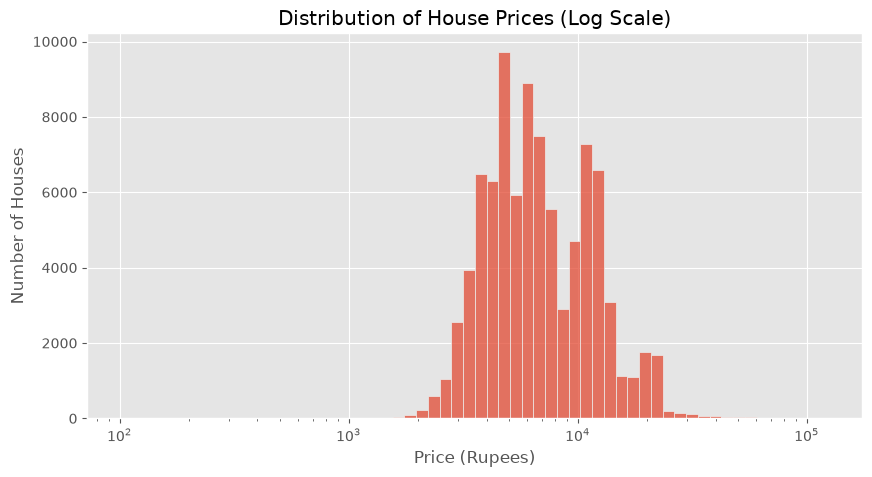

In [437]:
plt.figure(figsize=(10,5))

sns.histplot(df["price_clean"], bins=60, log_scale=True)

plt.title("Distribution of House Prices (Log Scale)")
plt.xlabel("Price (Rupees)")
plt.ylabel("Number of Houses")

plt.show()

### Observation

The distribution is highly right-skewed.

Most houses have relatively lower prices, while a small number of luxury properties have extremely high prices.

Using a logarithmic scale makes the distribution easier to visualize.

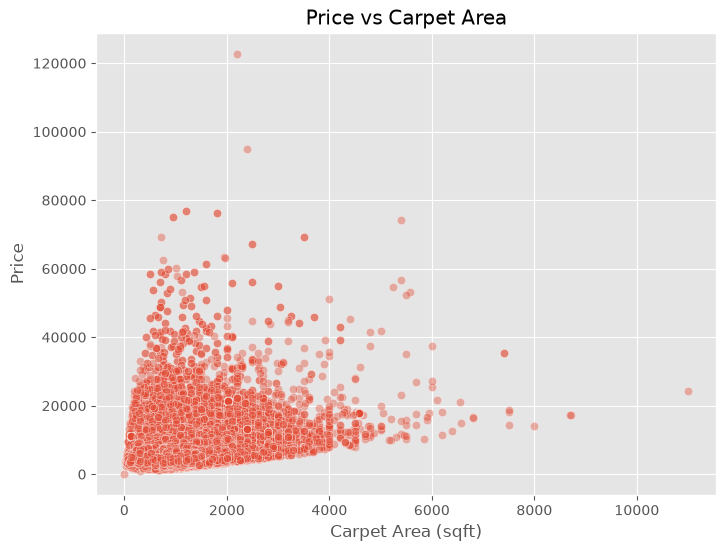

In [438]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="carpet_area_sqft",
    y="price_clean",
    alpha=0.4
)

plt.title("Price vs Carpet Area")

plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price")

plt.show()

### Observation

There is generally a positive relationship between carpet area and house price.

Larger houses tend to cost more, although there are several outliers.

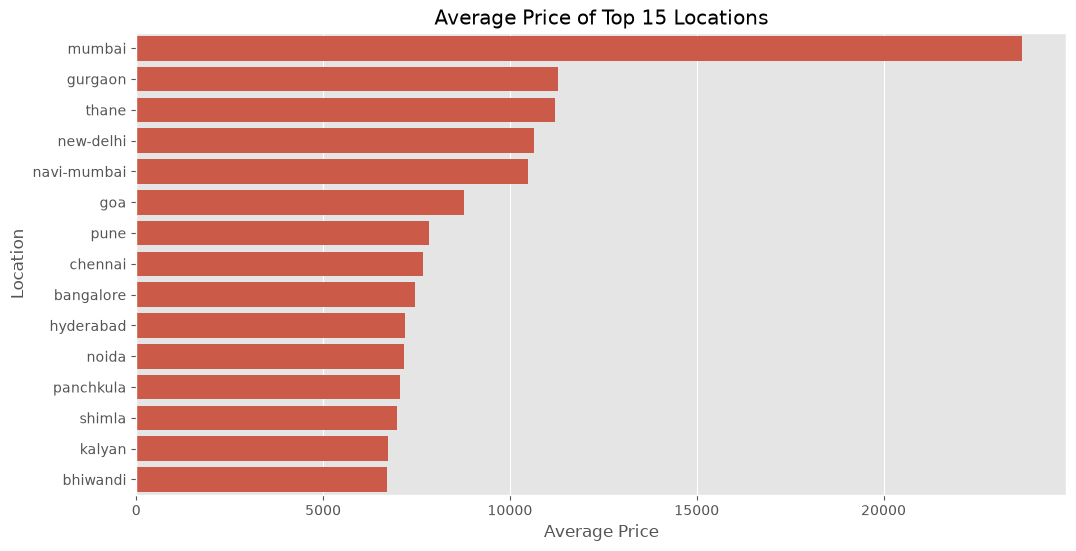

In [439]:
top_locations = (
    df.groupby("location")["price_clean"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index
)

plt.title("Average Price of Top 15 Locations")

plt.xlabel("Average Price")

plt.ylabel("Location")

plt.show()

### Observation

Some locations have significantly higher average prices than others.

Location appears to be one of the most important factors affecting house prices.

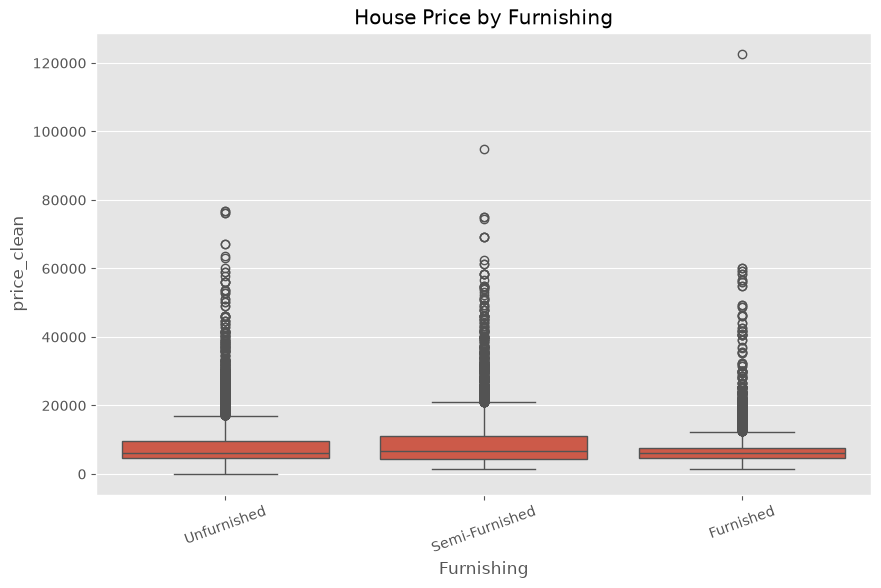

In [440]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Furnishing",
    y="price_clean"
)

plt.xticks(rotation=20)

plt.title("House Price by Furnishing")

plt.show()

### Observation

Furnished properties generally have higher prices than unfurnished properties.

The plot also shows several expensive outliers.

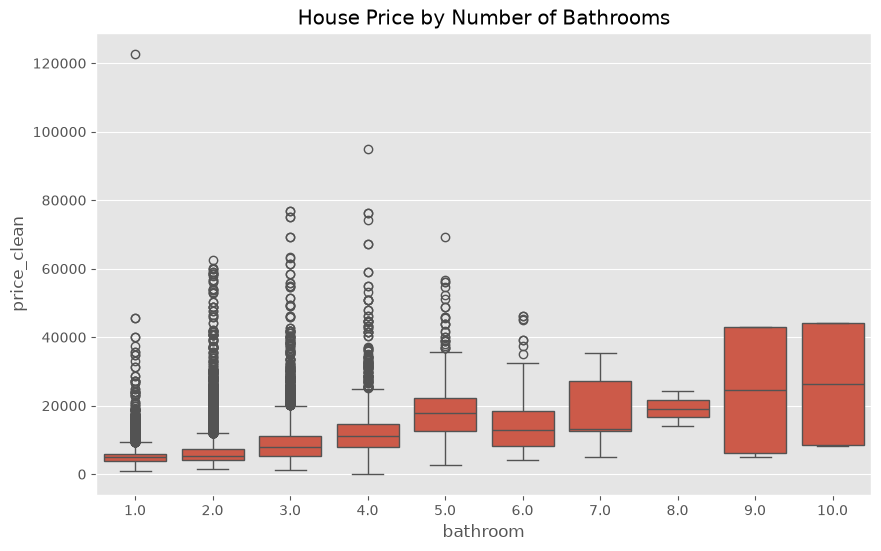

In [441]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="bathroom",
    y="price_clean"
)

plt.title("House Price by Number of Bathrooms")

plt.show()

### Observation

As the number of bathrooms increases, house prices generally increase.

This indicates that the number of bathrooms is an important predictive feature.

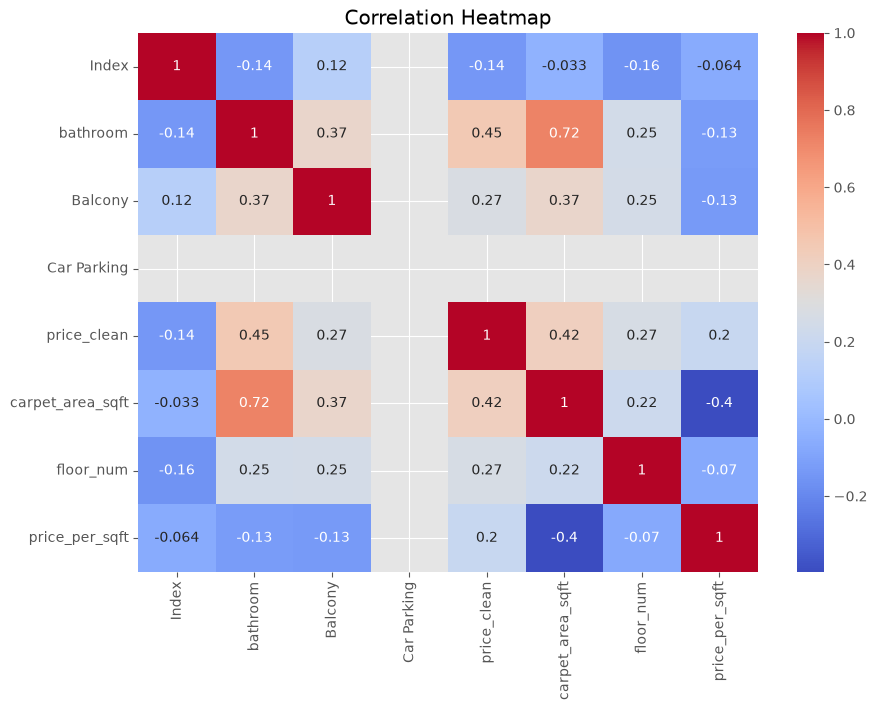

In [442]:
numeric_columns = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows the relationships between numeric features.

Positive values indicate features that increase together, while negative values indicate inverse relationships.

Features with stronger correlations may be more useful during model training.

# 2.4 Build the Machine Learning Pipeline

## Objective

In this section we prepare the dataset for machine learning.

We will:

- Select the input features
- Split the data into training and testing sets
- Build a preprocessing pipeline
- Train multiple machine learning models
- Compare their performance

In [443]:
numeric_features = [

    "carpet_area_sqft",
    "floor_num",
    "bathroom",
    "Balcony"

]

categorical_features = [

    "location_grouped",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"

]

X = df[numeric_features + categorical_features]

y = df["price_clean"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (89804, 9)
Target Shape : (89804,)


In [444]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 71843
Testing Samples : 17961


The dataset is divided into:

- 80% Training Data
- 20% Testing Data

The training data is used to build the model while the testing data evaluates how well it performs on unseen data.

In [445]:
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

In [446]:
numeric_transformer = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="median")),

        ("scaler", StandardScaler())

    ]

)

categorical_transformer = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="most_frequent")),

        ("encoder", OneHotEncoder(handle_unknown="ignore"))

    ]

)

preprocessor = ColumnTransformer(

    transformers=[

        ("num", numeric_transformer, numeric_features),

        ("cat", categorical_transformer, categorical_features)

    ]

)

The preprocessing pipeline automatically handles:

- Missing values
- Scaling numeric features
- Encoding categorical features

This allows the backend to use the same preprocessing during prediction.

In [447]:
linear_model = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", LinearRegression())

    ]

)

linear_model.fit(

    X_train,

    y_train

)

print("Linear Regression Training Complete")

Linear Regression Training Complete


In [ ]:
forest_model = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model",

            RandomForestRegressor(

                n_estimators=50,

                random_state=42

            )

        )

    ]

)

forest_model.fit(

    X_train,

    y_train

)

print("Random Forest Training Complete")

In [ ]:
linear_predictions = linear_model.predict(

    X_test

)

forest_predictions = forest_model.predict(

    X_test

)

Two different machine learning algorithms have been trained.

- Linear Regression
- Random Forest Regression

The next step is to compare their prediction accuracy.

# 2.5 Model Evaluation

## Objective

Evaluate both machine learning models using:

- MAE
- RMSE
- R² Score

The model with the best overall performance will be selected.

In [ ]:
from sklearn.metrics import (

    mean_absolute_error,

    root_mean_squared_error,

    r2_score

)

In [ ]:
linear_mae = mean_absolute_error(

    y_test,

    linear_predictions

)

linear_rmse = root_mean_squared_error(

    y_test,

    linear_predictions

)

linear_r2 = r2_score(

    y_test,

    linear_predictions

)

In [ ]:
forest_mae = mean_absolute_error(

    y_test,

    forest_predictions

)

forest_rmse = root_mean_squared_error(

    y_test,

    forest_predictions

)

forest_r2 = r2_score(

    y_test,

    forest_predictions

)

In [ ]:
results = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Random Forest"

    ],

    "MAE":[

        linear_mae,

        forest_mae

    ],

    "RMSE":[

        linear_rmse,

        forest_rmse

    ],

    "R2 Score":[

        linear_r2,

        forest_r2

    ]

})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,2042.585522,3057.092492,0.618394
1,Random Forest,586.031063,1685.376060,0.884018


In [ ]:
best_model = forest_model

print("Selected Model : Random Forest")

Selected Model : Random Forest


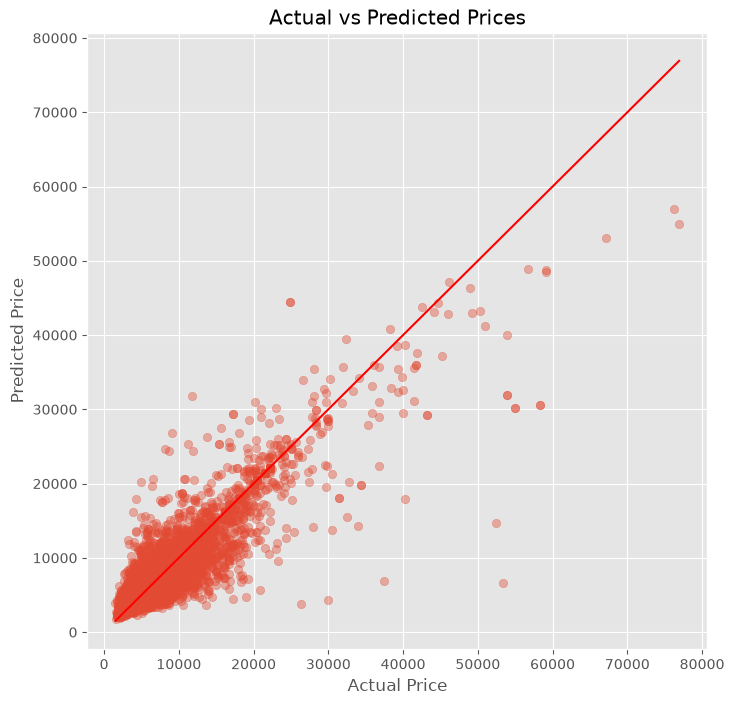

In [ ]:
plt.figure(figsize=(8,8))

plt.scatter(

    y_test,

    forest_predictions,

    alpha=0.4

)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    color="red"

)

plt.show()

### Observation

Most predicted values are close to the diagonal red line, indicating that the model makes reasonably accurate predictions.

Some errors remain because house prices are influenced by many factors that may not be fully captured in the dataset.

In [ ]:
#from sklearn.model_selection import cross_val_score

#scores = cross_val_score(

    #forest_model,

    #X,

    #y,

    #cv=5,

    #scoring="r2"

#)

#print("Cross Validation Scores")

#print(scores)

#print()

#print("Average Score")

#print(scores.mean())

KeyboardInterrupt: 

In [ ]:
joblib.dump(

    best_model,

    "house_price.pkl"

)

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
#Export Location
locations = sorted(

    df["location_grouped"].unique()

)

with open(

    "locations.json",

    "w"

) as f:

    json.dump(

        locations,

        f,

        indent=4

    )

print("Locations Saved Successfully")

Locations Saved Successfully


In [ ]:
loaded_model = joblib.load(

    "house_price.pkl"

)

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(

    sample

)

print("Sample Prediction")

print(prediction)

Sample Prediction
[20970.82]
